In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json

import sys

sys.path.append("..")

In [2]:
from src.models.kernel_empirical_risk import KernelEmpiricalRisk

In [3]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 22}
    plt.rc("font", **font)


set_style()

In [4]:
index = 1
input_params_path = "params/n{}.json".format(index)
input_predictors_path = "results/train_predictors/n{}/".format(index)
result_path = "results/best_predictor/n{}/".format(index)

# Selecting optimal parameter

In [5]:
def load_list_with_pickle(file_name):
    with open(file_name, "rb") as file:
        result = pickle.load(file)
    return result

In [6]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [7]:
def compute_empirical_risk(predictor, outputs):
    empirical_risk = KernelEmpiricalRisk(predictor.loss_name, predictor.loss_params)
    empirical_risk_value = empirical_risk.empirical_risk(
        predictor.model_weights,
        (predictor.scalar_gram_matrix, predictor.output_covariance),
        outputs,
        0,
    )
    return empirical_risk_value


def compute_corrected_empirical_risk(predictor, outputs):
    empirical_risk_value = compute_empirical_risk(predictor, outputs)
    loss_stability_bound = predictor.compute_loss_stability_bound()
    return empirical_risk_value + 2 * loss_stability_bound

In [8]:
input_params = reader(input_params_path)

{'index': 1, 'pre_data': {'seed': 0, 'sample_size': 500, 'input_dimension': 2, 'output_dimension': 2, 'covariance_matrix': [[1.0, 0.5], [0.5, 1.0]], 'pert': 'gaussian', 'n_anchors': 2}, 'data': {'sample_size': 500, 'input_dimension': 2, 'output_dimension': 2, 'covariance_matrix': [[1.0, 0.5], [0.5, 1.0]], 'pert': 'gaussian', 'n_anchors': 2}, 'loss_name': 'log_cosh', 'loss_params': {'alpha': 1.0}, 'kernel': 'laplacian', 'kernel_max': 1.0, 'solver': 'Newton-CG', 'lams_number': 20, 'lam_min': 0.001, 'lam_max': 0.5, 'rep_number': 100, 'confidence_control_level': 0.1, 'regularization_values': [1e-06], 'neighbor_numbers': [20]}


In [9]:
data_set = load_list_with_pickle(input_predictors_path + "dataset.pkl")

In [10]:
predictors_upper = []
predictors_split = []

index_tmp = 100
index_max = min(index_tmp, input_params["lams_number"])

for index in range(index_max):
    predictor_upper = load_list_with_pickle(
        input_predictors_path + "predictor_upper_{}.pkl".format(index)
    )
    predictors_upper.append(predictor_upper)

    predictor_split = load_list_with_pickle(
        input_predictors_path + "predictor_split_{}.pkl".format(index)
    )
    predictors_split.append(predictor_split)

corrected_empirical_risk_upper = np.array(
    [
        compute_corrected_empirical_risk(predictor, data_set["outputs"])
        for predictor in predictors_upper
    ]
)

corrected_empirical_risk_split = np.array(
    [
        compute_corrected_empirical_risk(predictor, data_set["train_outputs"])
        for predictor in predictors_split
    ]
)

[np.float64(0.001), np.float64(0.0013869188565300285), np.float64(0.0019235439145985594), np.float64(0.0026677993265203283), np.float64(0.0037000211913891536), np.float64(0.0051316291598983155), np.float64(0.007117153246582317), np.float64(0.009870914042498928), np.float64(0.013690156816728805), np.float64(0.018987136637974272), np.float64(0.02633361783471869), np.float64(0.03652259113562678), np.float64(0.05065387033533722), np.float64(0.07025280792430623), np.float64(0.09743494403440243), np.float64(0.13513436116626076), np.float64(0.18742039366662613), np.float64(0.2599368780745249), np.float64(0.36051135770910503), np.float64(0.5)]
[np.float64(0.001), np.float64(0.0013869188565300285), np.float64(0.0019235439145985594), np.float64(0.0026677993265203283), np.float64(0.0037000211913891536), np.float64(0.0051316291598983155), np.float64(0.007117153246582317), np.float64(0.009870914042498928), np.float64(0.013690156816728805), np.float64(0.018987136637974272), np.float64(0.026333617834

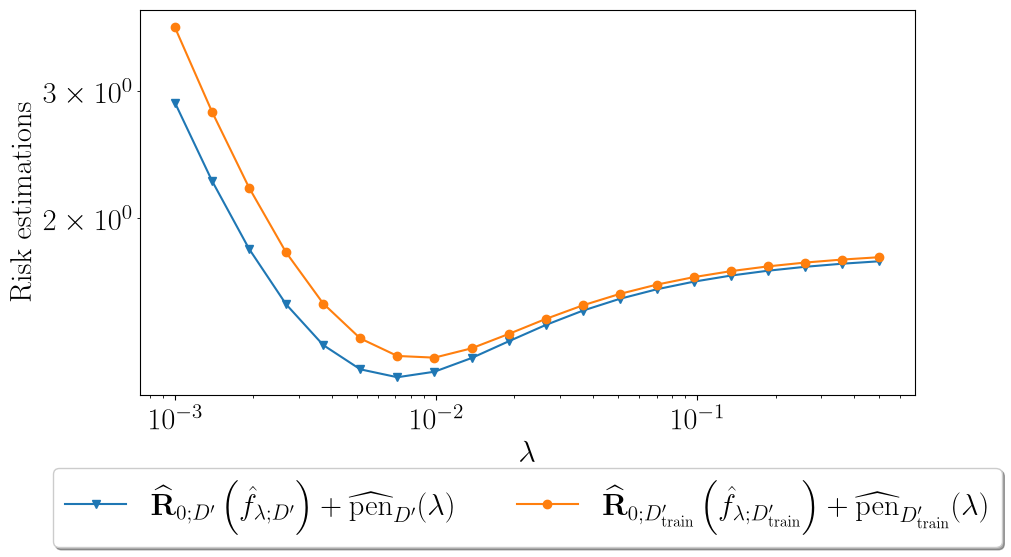

In [11]:
lams = [predictor.lam for predictor in predictors_upper]
print(lams)

lams = [predictor.lam for predictor in predictors_split]
print(lams)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    lams, corrected_empirical_risk_upper,
    label=r"$\widehat{\mathbf{R}}_{0; D^{\prime}}\left(\hat{f}_{\lambda; D^{\prime}}\right) + \widehat{\mathrm{pen}}_{D^{\prime}}(\lambda)$",
    marker="v"
)
ax.plot(
    lams,
    corrected_empirical_risk_split,
    label=r"$\widehat{\mathbf{R}}_{0; D^{\prime}_{\mathrm{train}}}\left(\hat{f}_{\lambda; D^{\prime}_{\mathrm{train}}}\right) + \widehat{\mathrm{pen}}_{D^{\prime}_{\mathrm{train}}}(\lambda)$",
    marker="o",
)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel("$\\lambda$")
ax.set_ylabel("Risk estimations")
#ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
# Put a legend below current axis
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=2)

In [12]:
lam_upper = lams[np.argmin(corrected_empirical_risk_upper)]
lam_split = lams[np.argmin(corrected_empirical_risk_split)]
result = {"lam_upper": lam_upper, "lam_split": lam_split}
print(result)

{'lam_upper': np.float64(0.007117153246582317), 'lam_split': np.float64(0.009870914042498928)}


In [13]:
def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

In [14]:
save_list_with_pickle(result, result_path + "lam.pkl")

In [15]:
fig.savefig(
    result_path + "risk_estimations" + ".eps", format="eps", bbox_inches="tight"
)
fig.savefig(
    result_path + "risk_estimations" + ".jpeg", format="jpeg", bbox_inches="tight"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.
